# Модель для прогнозирования оттока клиентов для сервиса доставки кофе

### Описание проекта
**Happy Beans Coffee** - компания, запустившая новый сервис по доставке элитного кофе, ежемесячно теряет 10% клиентов, что приводит к потере выручки. Привлечение нового клиента обходится в 5-7 раз дороже, чем удержание существующего. Поэтому критически важно выявлять клиентов на грани ухода, чтобы своевременно принять меры по удержанию: персональные скидки, промокоды и специальные акции.

**Задача проекта:** разработать модель бинарной классифиакции на основе **LogisticRegression**, которая спрогнозирует вероятность оттока каждого клиента в следующем месяце. 

**Метрики качества:** <br>
- PR AUC (Precision-Recall AUC) - основная метрика: в условиях сильного дисбаланса классов лучше отражает качество работы с миноритарным классом (оттоком), чем ROC AUC.
- Дополнительно анализируются:
<br>Recall - доля реально ушедших клиентов, которых модель обнаружила
<br>Precision - доля верных предсказаний оттока среди всех предсказанных

## Описание данных

Датасет `coffee_churn_dataset` - представлен в виде готовой аналитической витрины, в которой все признаки уже вычислены и представлены в виде числовых и категориальных значений. 
- `user_id` — идентификатор пользователя.
- `days_since_last_order` — количество дней, прошедших с последнего заказа.
- `order_frequency_month` — среднее число заказов в месяц.
- `order_frequency_week` — среднее число заказов в неделю.
- `avg_order_value` — средний чек, в рублях.
- `median_order_value` — медианный чек, в рублях.
- `total_spent_last_month` — сумма заказов за последний месяц.
- `total_spent_last_week` — сумма заказов за последнюю неделю.
- `discount_usage_rate` — доля заказов со скидкой за последний месяц.
- `last_coffee_type` — сорт кофе, купленный пользователем в последний раз на момент сбора данных.
- `preferred_roast` — предпочитаемый тип обжарки.
- `milk_preference` — предпочитаемый тип молока.
- `seasonal_menu_tried` — отметка о том, пробовал ли пользователь новейшее сезонное меню.
- `coffee_bean_origin` — страна происхождения зерна.
- `last_drink_size` — размер последнего заказа, совершённого на момент сбора данных.
- `subscription_status` — тип подписки пользователя.
- `app_opens_per_week` — сколько раз за неделю пользователь в среднем открывал приложение доставки кофе.
- `notifications_enabled` — включены ли у пользователя уведомления.
- `review_rating_last_10` — средняя оценка последних на момент сбора данных десяти заказов клиента.
- `review_rating_last_1` — оценка последнего на момент сбора данных заказа клиента.
- `app_crashes_last_month` — сколько раз приложение зависало за последний месяц.
- `seasons` — текущее время года.
- `days_since_last_promo` — сколько дней прошло с последнего использования акции или промокода.
- `phone_type` — тип устройства, с которого пользователь чаще всего совершал покупки.
- `coffee_preference_change` — менялись ли вкусовые предпочтения пользователя.
- `geo_id` — идентификатор региона пользователя.
- `churn` — перестал ли пользователь пользоваться сервисом. **Целевая переменная**

## Шаги выполнения

1. **Подготовка среды** — библиотеки, `random_state`, загрузка CSV
2. **Первичный анализ данных (EDA)** — целевая переменная, признаки, пропуски, категориальные переменные, выбросы, корреляции
3. **Предобработка данных** — разбивка train/test, пайплайны
4. **Базовая модель** — DummyClassifier + LogisticRegression с кросс-валидацией
5. **Feature Engineering** — новые признаки, интерпретация коэффициентов<!--  -->
6. **Гиперпараметры** — GridSearchCV по LogisticRegression
7. **Финальная модель** — оценка на тестовой выборке
8. **Отчёт** — анализ итогов и бизнес-выводы
9. **Сохранение модели** — экспорт через `joblib`

# План работы

## Этап 1. Подготовка среды и библиотек
1. Установите и настройте библиотеки. Для воспроизводимости результатов зафиксируйте версии пакетов в файле `requirements.txt`.

2. Зафиксируйте `random_state`.

3. Загрузите данные из CSV-файла. Путь к файлу: `'/datasets/coffee_churn_dataset.csv'`. Используйте сепаратор `","`, а для чтения чисел с плавающей точкой — параметр `decimal="."`.

In [1]:
# 1.1 Импортирую библиотеки
import os
import warnings
warnings.filterwarnings('ignore')
!pip install phik --quiet
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from phik import phik_matrix

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.model_selection import RandomizedSearchCV, cross_val_score, GridSearchCV, StratifiedKFold, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, classification_report, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler

In [2]:
# 1.2 Фиксирую random_state
RANDOM_STATE = 42
np.random.seed (RANDOM_STATE)

In [3]:
# 1.3 Загружаю данные из CSV-файла
df = pd.read_csv('https://code.s3.yandex.net/datasets/coffee_churn_dataset.csv', sep=',', decimal='.')
print(f"Данные загружены: датасет содержит {df.shape[0]} строк, {df.shape[1]} столбцов.")
df.head()

Данные загружены: датасет содержит 10450 строк, 27 столбцов.


,user_id,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,...,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,seasons,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
0,user_00318,0.0,12.942519,NaN,316.833872,260.645090,3089.991009,NaN,0.337031,blend,...,1.0,5.176792,3.302238,NaN,summer,6.0,android,0.0,geo_75,1
1,user_07234,2.0,1.569146,0.214494,780.135158,540.597850,998.380941,107.369409,0.547659,arabica,...,1.0,4.392991,NaN,0.0,autumn,16.0,ios,0.0,geo_95,0
2,user_04816,11.0,2.996666,0.771864,682.636256,471.494559,1328.140204,392.600011,0.120258,arabica,...,1.0,4.977712,4.379219,0.0,spring,11.0,web,1.0,geo_25,0
3,user_04419,0.0,4.299255,1.210480,2115.487425,708.529812,2999.628366,1084.352054,NaN,robusta,...,1.0,3.712526,3.043618,0.0,summer,3.0,android,0.0,geo_2,0
4,user_09698,3.0,7.249864,1.761027,3519.602170,1199.372894,8377.729478,2551.775211,0.074990,robusta,...,0.0,4.528271,5.642993,1.0,winter,14.0,ios,0.0,geo_19,1


---
**Промежуточный вывод**
- Выгружены необходимые библиотеки. Зафиксирован RANDOM_STATE для воспроизводимости. Загружены данные для дальнейшей работы.

## Этап 2. Первичный анализ данных

1. Опишите данные. Кратко сообщите, что известно о пользователях и их поведении.

2. Опишите целевую переменную. Обратите внимание на возможные особенности её распределения. Проверьте, наблюдается ли дисбаланс классов в целевой переменной.

3. Опишите признаки.

   - Определите, все ли из них важны.

   - Объясните, какие из них можно удалить (если такие есть). Аргументируйте своё решение.

4. Обработайте пропущенные значения.
   
   - Объясните, как они влияют на данные.

   - Выберите стратегию заполнения пропусков.

5. Проанализируйте категориальные признаки.

   - Выясните, есть ли в данных признаки, которые можно кодировать. Объясните, почему именно их нужно кодировать.

   - Проанализируйте признаки на предмет того, можно ли использовать некоторые из них для генерации новых  признаков. Укажите возможные стратегии.

   - Определите, есть ли в данных признаки, которые можно удалить.

6. Проанализируйте выбросы.

   - Определите, как они влияют на данные.

   - Выберите способ, которым их можно обработать.

7. Посчитайте корреляции между признаками. Постройте необходимые визуализации. Определите, есть ли признаки, которые можно убрать, на основании их корреляции с другими.

8. Напишите выводы по результатам исследовательского анализа данных.

In [4]:
# 2.1 Вывожу общую информацию о датасете
print ('Общая информация о датасете')
df.info()

Общая информация о датасете
<class 'pandas.DataFrame'>
RangeIndex: 10450 entries, 0 to 10449
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   10450 non-null  str    
 1   days_since_last_order     9505 non-null   float64
 2   order_frequency_month     9850 non-null   float64
 3   order_frequency_week      10062 non-null  float64
 4   avg_order_value           9867 non-null   float64
 5   median_order_value        9619 non-null   float64
 6   total_spent_last_month    10156 non-null  float64
 7   total_spent_last_week     9506 non-null   float64
 8   discount_usage_rate       10053 non-null  float64
 9   last_coffee_type          10192 non-null  str    
 10  preferred_roast           10334 non-null  str    
 11  milk_preference           9782 non-null   str    
 12  seasonal_menu_tried       9461 non-null   float64
 13  coffee_bean_origin        9768 non-null   st

Датасет `coffee_churn_dataset` содержит 27 столбцов и 10450 строк. 
<br>После первичного анализа данных можно сделать следующие выводы:
- Названия столбцов соответствуют общепринятому формату - snake case.
- Представленные данные содержат числовые и строковые значения.  
- Пропуски обнаружены в 25 столбцах. Необходим более подробный анализ пропусков.
- Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию.


In [5]:
print ('Статистические показатели')
df.describe()

Статистические показатели


,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,seasonal_menu_tried,app_opens_per_week,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,days_since_last_promo,coffee_preference_change,churn
count,9505.000000,9850.000000,10062.000000,9867.000000,9619.000000,10156.000000,9506.000000,10053.000000,9461.000000,9554.000000,9913.000000,9757.000000,9593.000000,9729.000000,9719.000000,9840.000000,10450.000000
mean,4.394214,4.025666,0.930686,1063.741207,452.651500,1946.132979,413.004760,0.284446,0.701194,11.330895,0.753052,4.206709,4.022460,1.013362,14.554584,0.192480,0.060191
std,4.858757,2.826144,0.657261,707.713396,258.657571,2370.619590,445.634902,0.158735,0.457759,14.528887,0.431258,0.782212,1.207883,1.010342,15.308869,0.394268,0.237852
min,0.000000,0.011046,-0.169131,-32.075932,-10.353340,-43.716463,-2290.559468,0.002162,0.000000,0.000000,0.000000,1.415526,-0.897000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.937767,0.445185,552.898663,262.908598,629.680382,136.565833,0.159884,0.000000,6.313628,1.000000,3.675543,3.214157,0.000000,4.000000,0.000000,0.000000
50%,3.000000,3.381094,0.784839,898.643524,406.456818,1300.409757,288.277327,0.264583,1.000000,9.228383,1.000000,4.203555,3.990032,1.000000,10.000000,0.000000,0.000000
75%,6.000000,5.439363,1.262350,1406.332153,590.418070,2481.650495,549.699420,0.387056,1.000000,12.726649,1.000000,4.717292,4.845225,2.000000,20.000000,0.000000,0.000000
max,40.000000,27.389318,6.302624,5901.965278,2189.101644,79298.849570,8615.988952,0.887301,1.000000,224.587876,1.000000,7.384425,8.558443,7.000000,140.000000,1.000000,1.000000


In [6]:
# 2.2 Целевая переменная
print("Распределение целевой переменной:")
churn_counts = df['churn'].value_counts()
churn_pct    = df['churn'].value_counts(normalize=True) * 100
print(f"  Не ушли (0): {churn_counts[0]:,}  ({churn_pct[0]:.1f}%)")
print(f"  Ушли    (1): {churn_counts[1]:,}   ({churn_pct[1]:.1f}%)")
print(f"  Дисбаланс: {churn_counts[0] / churn_counts[1]:.1f}:1")

Распределение целевой переменной:
  Не ушли (0): 9,821  (94.0%)
  Ушли    (1): 629   (6.0%)
  Дисбаланс: 15.6:1


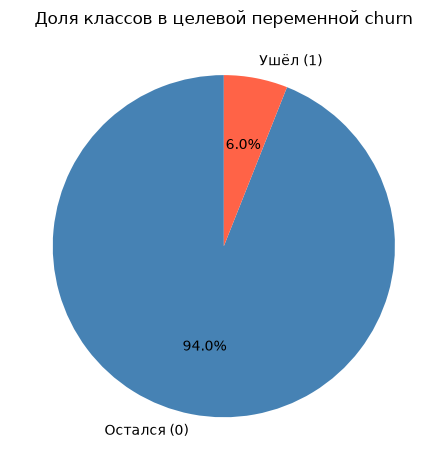

In [7]:
# Визуализирую распределение классов в целевой переменной
plt.pie(churn_counts.values, labels=['Остался (0)', 'Ушёл (1)'],
    colors=['steelblue', 'tomato'], autopct='%1.1f%%', startangle=90)
plt.title('Доля классов в целевой переменной churn')
plt.tight_layout()
plt.show()

В целевой переменной наблюдается существенный дисбаланс классов.

In [8]:
# 2.3 Описание признаков
num_cols = df.select_dtypes(include='number').columns.drop('churn').tolist()
cat_cols = df.select_dtypes(include='str').columns.tolist()
print(f"Числовые признаки ({len(num_cols)}): {num_cols}")
print(f"Категориальные ({len(cat_cols)}): {cat_cols}")

Числовые признаки (16): ['days_since_last_order', 'order_frequency_month', 'order_frequency_week', 'avg_order_value', 'median_order_value', 'total_spent_last_month', 'total_spent_last_week', 'discount_usage_rate', 'seasonal_menu_tried', 'app_opens_per_week', 'notifications_enabled', 'review_rating_last_10', 'review_rating_last_1', 'app_crashes_last_month', 'days_since_last_promo', 'coffee_preference_change']
Категориальные (10): ['user_id', 'last_coffee_type', 'preferred_roast', 'milk_preference', 'coffee_bean_origin', 'last_drink_size', 'subscription_status', 'seasons', 'phone_type', 'geo_location']


In [9]:
# 2.4 Пропущенные значения
miss_val = df.isnull().sum()
miss_pct = (miss_val / len(df)) * 100
miss_df = pd.DataFrame({
    'Количество пропусков': miss_val,
    'Процент пропусков': miss_pct
})
miss_df = miss_df[miss_df['Количество пропусков'] > 0].sort_values('Процент пропусков', ascending=False)
print("Анализ пропусков в признаках:")
print(miss_df)

Анализ пропусков в признаках:
                          Количество пропусков  Процент пропусков
seasonal_menu_tried                        989           9.464115
days_since_last_order                      945           9.043062
total_spent_last_week                      944           9.033493
subscription_status                        938           8.976077
app_opens_per_week                         896           8.574163
review_rating_last_1                       857           8.200957
median_order_value                         831           7.952153
days_since_last_promo                      731           6.995215
app_crashes_last_month                     721           6.899522
review_rating_last_10                      693           6.631579
coffee_bean_origin                         682           6.526316
seasons                                    679           6.497608
milk_preference                            668           6.392344
coffee_preference_change                   610

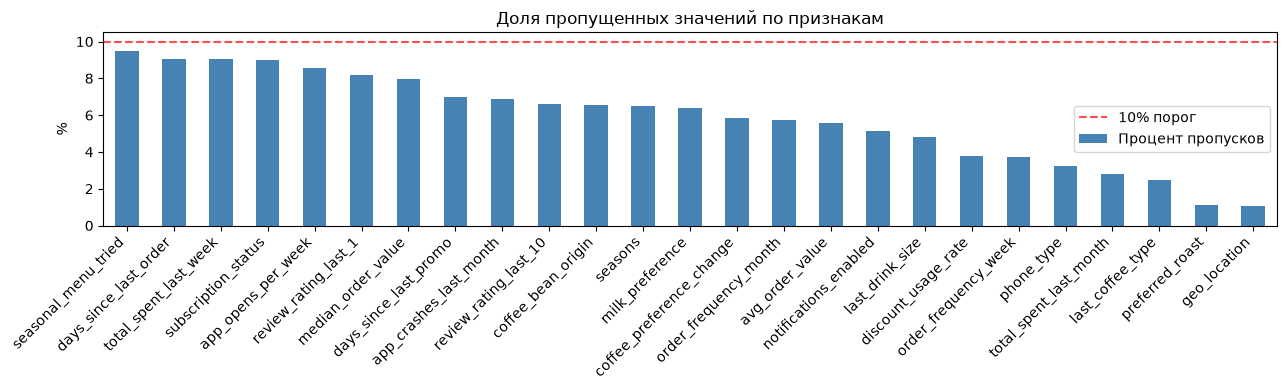

In [10]:
miss_df['Процент пропусков'].plot(kind='bar', color='steelblue', figsize=(13,4))
plt.axhline(10, color='red', linestyle='--', alpha=0.7, label='10% порог')
plt.title('Доля пропущенных значений по признакам')
plt.ylabel('%')
plt.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [11]:
# 2.5 Категориальные данные (user_id не категориальный признак, а уникальный идентификатор)
cat_cols = [col for col in cat_cols if col != 'user_id']

for col in cat_cols:
    uvals = sorted(df[col].dropna().unique())
    n = len(uvals)
    shown = uvals if n <= 10 else uvals[:6] 
    print(f"{col} ({n}): {shown}")

    # Проверка на неявные дубликаты
    normalized = df[col].dropna().str.lower().str.strip()
    n_norm = normalized.nunique()
    if n_norm < n:
        print(f"[!] Возможные дубликаты после нормализации: {n} -> {n_norm} уникальных")

last_coffee_type (3): ['arabica', 'blend', 'robusta']
preferred_roast (3): ['dark', 'light', 'medium']
milk_preference (6): ['almond', 'none', 'oat', 'skim', 'soy', 'whole']
coffee_bean_origin (6): ['brazil', 'colombia', 'ethiopia', 'guatemala', 'kenya', 'vietnam']
last_drink_size (3): ['large', 'medium', 'small']
subscription_status (4): ['basic', 'none', 'premium', 'pro']
seasons (4): ['autumn', 'spring', 'summer', 'winter']
phone_type (3): ['android', 'ios', 'web']
geo_location (100): ['geo_1', 'geo_10', 'geo_100', 'geo_11', 'geo_12', 'geo_13']


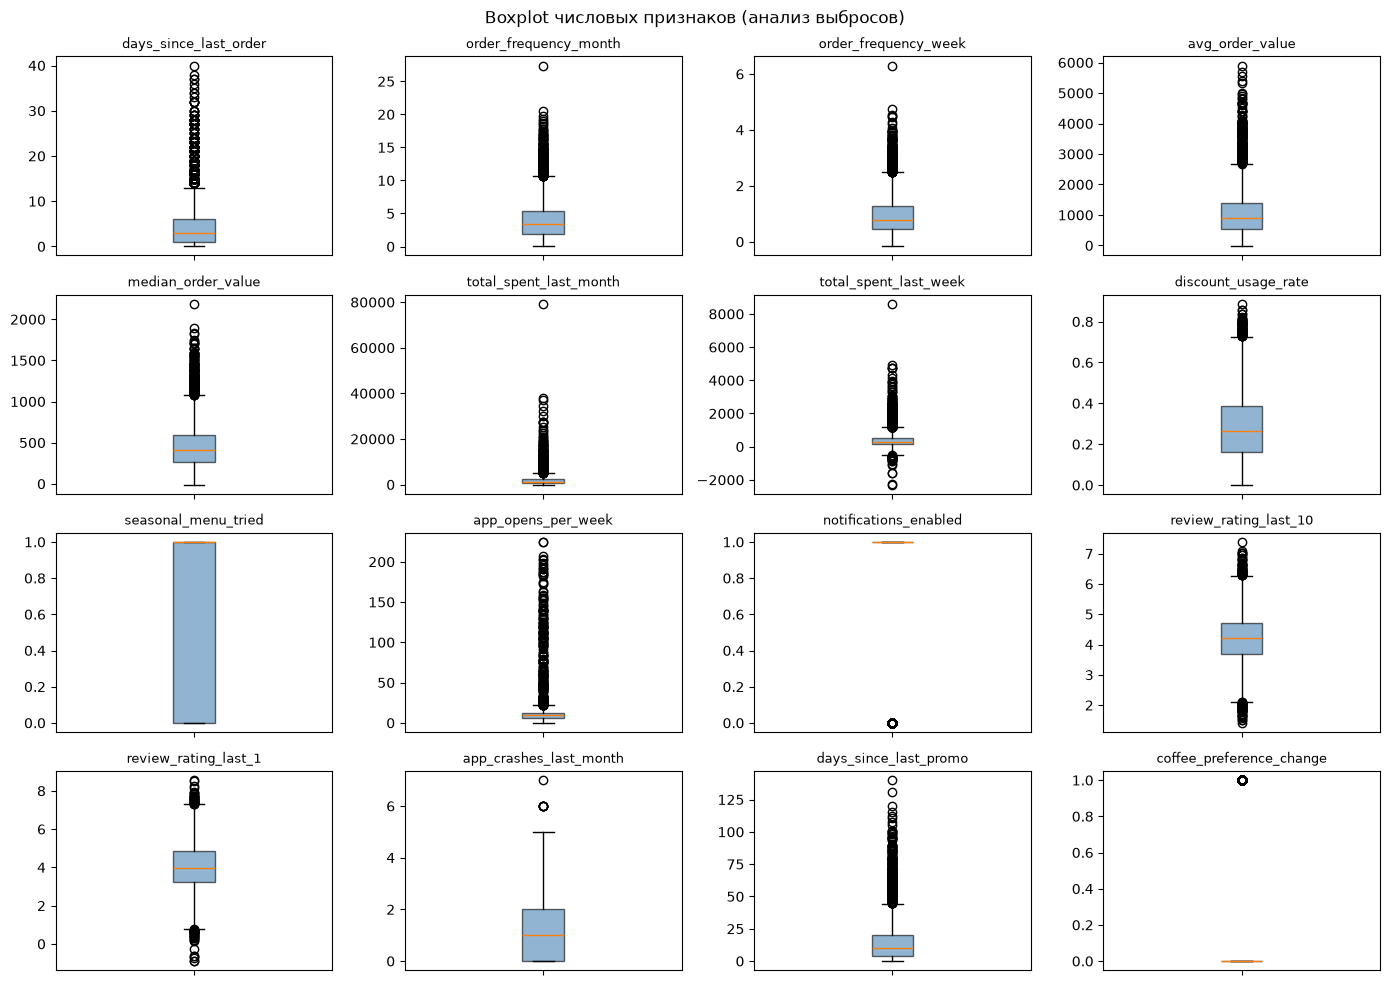

In [12]:
# 2.6 Выбросы
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(col, fontsize=9)
    axes[i].tick_params(labelbottom=False)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Boxplot числовых признаков (анализ выбросов)', fontsize=12)
plt.tight_layout()
plt.show()

interval columns not set, guessing: ['days_since_last_order', 'order_frequency_month', 'order_frequency_week', 'avg_order_value', 'median_order_value', 'total_spent_last_month', 'total_spent_last_week', 'discount_usage_rate', 'seasonal_menu_tried', 'app_opens_per_week', 'notifications_enabled', 'review_rating_last_10', 'review_rating_last_1', 'app_crashes_last_month', 'days_since_last_promo', 'coffee_preference_change', 'churn']


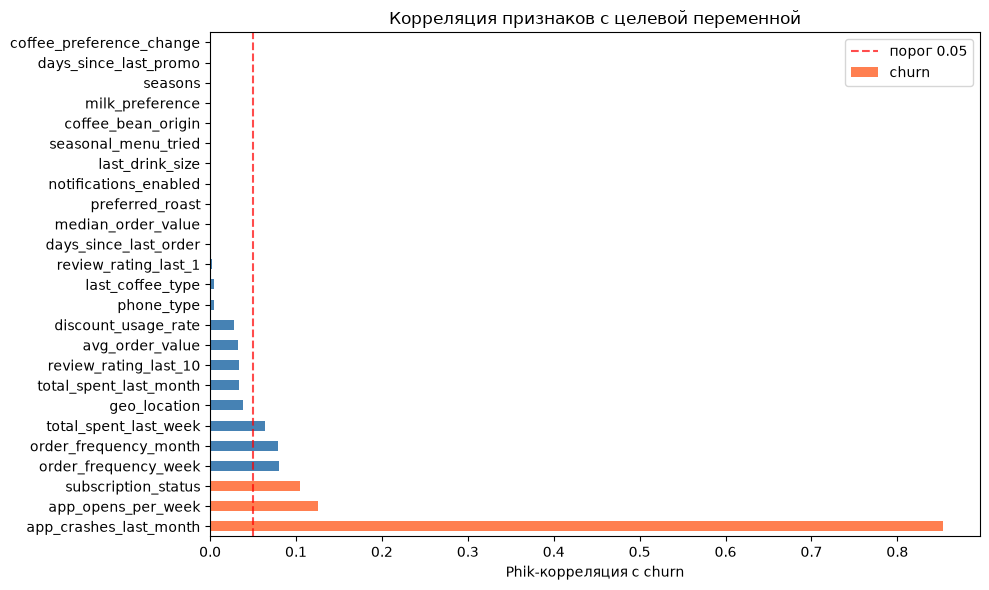

In [13]:
# 2.7 Корреляция
features_for_phik = df.drop(columns=['user_id'])
phik_matrix = features_for_phik.phik_matrix()
corr_with_churn = phik_matrix['churn'].drop('churn').sort_values(ascending=False)

plt.figure(figsize=(10, 6))
colors = ['coral' if x > 0.1 else 'steelblue' for x in corr_with_churn.values]
corr_with_churn.plot(kind='barh', color=colors)
plt.xlabel('Phik-корреляция с churn')
plt.title('Корреляция признаков с целевой переменной')
plt.axvline(x=0.05, color='red', linestyle='--', alpha=0.7, label='порог 0.05')
plt.legend()
plt.tight_layout()
plt.show()

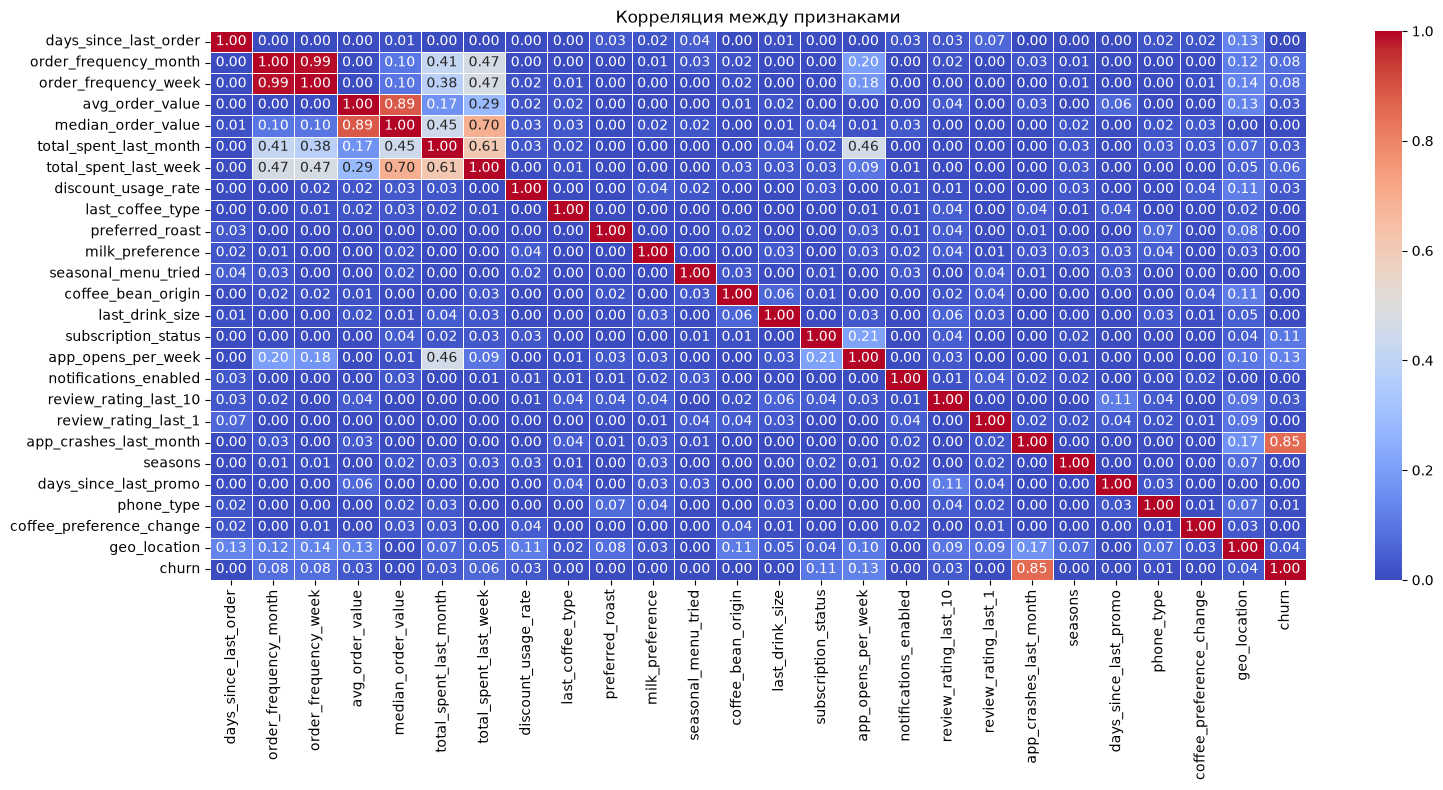

In [14]:
# Мультиколлинеарность
plt.figure(figsize=(16, 8))
sns.heatmap(data=phik_matrix,
             annot=True, fmt='.2f', linewidths=0.5, cmap='coolwarm')
plt.title ('Корреляция между признаками')
plt.tight_layout()
plt.show()

---
### Промежуточный вывод по первичному анализу данных
1. **Целевая переменная.**  Датасет содержит сильный дисбаланс классов 94% клиентов остались, 6% ушли. Это означает, что классификатор, всегда предсказывающий «остался», даст 94% accuracy, но нулевой Recall по классу «ушёл». Поэтому необходимо применять `class_weight='balanced'` и оценивать модель через `PR-AUC`.
2. **Пропущенные значения.** Пропуски есть в 25 из 27 столбцов (5–9.5%). Удалять признаки нецелесообразно, т.к. информация ценна. Решение: числовые признаки - заменяем медианой (не средним арифметическим, потому что есть выбросы, которые могут повлиять на показатель); категориальные признаки - заменяем константой (наиболее часто встречающийся показатель).
3. **Категориальные признаки.** Все будут кодироваться через `OneHotEncoder(handle_unknown='ignore')`, что позволит безопасно обработать новые значения в дальнейшем. 
4. **Выбросы:** Обнаружены в денежных показателях (`avg_order_value`, `total_spent_*`). Применяем `RobustScaler` вместо `StandardScaler`, т.к. он устойчив к выбросам.
5. **Мультиколлинеарность.** Удаляем `order_frequency_week` (r=0.99 с `order_frequency_month`) и `median_order_value` (r=0.89 с `avg_order_value`). Также удаляем `user_id` как идентификатор без предсказательной силы.
6. **Корреляция с churn** Числовые признаки показывают слабую линейную корреляцию с целевой переменной, что типично для задач оттока, важны нелинейные взаимодействия и категориальные признаки.

## Этап 3. Предобработка данных

1. Разделите данные в пропорции 80 к 20. 20% данных отложите для теста. Остальные используйте для обучения и кросс-валидации модели.

2. Предобработайте данные. Используйте информацию о пропусках и категориальных признаках только из обучающей выборки.

   - Создайте пайплайн, который обработает пропуски и выбросы.

   - Создайте пайплайн, который обработает категориальные признаки.

   - Создайте пайплайн, который обработает числовые признаки: проведёт масштабирование и нормализацию.



In [15]:
# Перед разделением на выборки удаляю уникальный идентификатор и мультиколлинеарные признаки
DROP_COLS = ['user_id', 'order_frequency_week', 'median_order_value']

X = df.drop(columns=DROP_COLS + ['churn'])
y = df['churn']
print(f"Признаков после удаления: {X.shape[1]}  (удалено {len(DROP_COLS)})")

Признаков после удаления: 23  (удалено 3)


In [16]:
# 3.1 Разделение данных на выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y,
)
print(f"Размер обучающей выборки: {X_train.shape[0]} строк, {X_train.shape[1]} признаков")
print(f"Размер тестовой выборки: {X_test.shape[0]} строк, {X_test.shape[1]} признаков")
print(f"\nДоля оттока в train: {y_train.mean():.2f}")
print(f"Доля оттока в test:  {y_test.mean():.2f}  (стратификация сохранена)")

Размер обучающей выборки: 8360 строк, 23 признаков
Размер тестовой выборки: 2090 строк, 23 признаков

Доля оттока в train: 0.06
Доля оттока в test:  0.06  (стратификация сохранена)


In [17]:
# 3.2 Предобработка данных (использую только train)
cat_features = X_train.select_dtypes(include='str').columns.tolist()
num_features   = X_train.select_dtypes(include='number').columns.tolist()

print(f"\nЧисловые признаки ({len(num_features)}): {num_features}")
print(f"\nКатегориальные ({len(cat_features)}): {cat_features}")


Числовые признаки (14): ['days_since_last_order', 'order_frequency_month', 'avg_order_value', 'total_spent_last_month', 'total_spent_last_week', 'discount_usage_rate', 'seasonal_menu_tried', 'app_opens_per_week', 'notifications_enabled', 'review_rating_last_10', 'review_rating_last_1', 'app_crashes_last_month', 'days_since_last_promo', 'coffee_preference_change']

Категориальные (9): ['last_coffee_type', 'preferred_roast', 'milk_preference', 'coffee_bean_origin', 'last_drink_size', 'subscription_status', 'seasons', 'phone_type', 'geo_location']


In [18]:
# Пайплайн для числовых признаков
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  RobustScaler()),
])
# Пайплайн для категориальных признаков
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore')),
])
# Объединенный ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_features),
        ('cat', cat_pipeline, cat_features),
    ],
    remainder='drop',
)

X_train_processed = preprocessor.fit_transform(X_train)
print(f"Размер после предобработки (train): {X_train_processed.shape}")

Размер после предобработки (train): (8360, 146)


---
**Промежуточный вывод**
- Данные разделены на тестовую (20%) и тренировочную выборки(80%). 
- Создан пайплайн для обработки данных по обучающей выборке.

## Этап 4. Обучение модели

1. Обучите базовую версию модели.
   - Используйте для этого простые статистические модели.

   - Используйте кросс-валидацию для обучения модели.

2. Посчитайте метрики, поставленные в задаче. Опираясь на них, сделайте вывод о качестве модели.

In [19]:
# Создаю функцию для рассчета метрик
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def cv_metrics(pipeline, X, y, cv, model_name='Model'):
    recall  = cross_val_score(pipeline, X, y, cv=cv, scoring='recall').mean()
    prec    = cross_val_score(pipeline, X, y, cv=cv, scoring='precision').mean()
    pr_auc  = cross_val_score(pipeline, X, y, cv=cv, scoring='average_precision').mean()
    return {
        'Модель':     model_name,
        'Recall':     round(recall,  4),
        'Precision':  round(prec,    4),
        'PR AUC':     round(pr_auc,  4),
    }

results = []

In [20]:
# 4.1.1 Обучаю DummyClassifier (most_frequent): базовый уровень
dummy_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE))
])

results.append (cv_metrics(dummy_pipeline, X_train, y_train, cv, 'DummyClassifier (most_frequent)'))

In [21]:
# 4.1.2 Обучаю LogisticRegression с учетом дисбаланса классов 
log_reg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000, class_weight='balanced'))
])
results.append (cv_metrics(log_reg_pipeline, X_train, y_train, cv, 'LogisticRegression'))

In [22]:
# Вывожу результат
results_df = pd.DataFrame(results)
results_df

,Модель,Recall,Precision,PR AUC
0,DummyClassifier (most_frequent),0.0000,0.0000,0.0602
1,LogisticRegression,0.8209,0.2867,0.5920


---
**Промежуточный вывод**
1. *DummyClassifier.* Является нижней границей. PR-AUC = 0,06, что соответствует доле оттока.
2. *LogisticRegression.* PR-AUC = 0.592, что значительно лучше нижней границы. Это подтверждает, что признаки действительно несут информацию об оттоке. Recall = 0.8209 - хороший показатель для данной задачи, т.к. дешевле предложить скидку (акцию и тд) "лишнему" клиенту, чем пропустить настоящий отток.

## Этап 5. Создание новых признаков

1. Добавьте новые признаки, которые могут улучшить качество модели. Опирайтесь на наработки, полученные в ходе исследовательского анализа данных, и на логику решаемой задачи.

   - Извлечение квадратного корня поможет сгладить большие значения.

   - Возведение в квадрат усилит влияние больших значений.

2. Обновите пайплайн для работы с новыми признаками, проведите повторную кросс-валидацию, сравните результаты моделей с новыми признаками и без них.

3. Интерпретируйте коэффициенты модели, а затем на их основании выявите значимые признаки и удалите лишние для модели.

In [23]:
# 5.1  
# Создаю трансформер для новых признаков
class FeatureEngineer(BaseEstimator, TransformerMixin):
    """
    Генерирует дополнительные признаки:
    - sqrt: сглаживает большие значения
    - sq:   усиливает влияние большых значений
    """
    SQRT_COLS = [
        'days_since_last_order', 'total_spent_last_month',
        'avg_order_value', 'days_since_last_promo',
    ]
    SQ_COLS = ['order_frequency_month', 'app_opens_per_week']
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        for col in self.SQRT_COLS:
            if col in X.columns:
                X[f'{col}_sqrt'] = np.sqrt(X[col].clip(lower=0))
        for col in self.SQ_COLS:
            if col in X.columns:
                X[f'{col}_sq'] = X[col] ** 2
        return X

In [24]:
# Применяю Feature Engineering
fe = FeatureEngineer()
X_train_fe = fe.fit_transform(X_train)
X_test_fe = fe.transform(X_test)

# Определяю новые колонки
new_sqrt_cols = [f'{col}_sqrt' for col in FeatureEngineer.SQRT_COLS]
new_sq_cols = [f'{col}_sq' for col in FeatureEngineer.SQ_COLS]
new_features_total = new_sqrt_cols + new_sq_cols

print(f"Добавлено признаков: {len(new_features_total)}")
print(f"  sqrt: {new_sqrt_cols}")
print(f"  sq:   {new_sq_cols}")

# Обновляю списки числовых колонок
num_cols_original = X_train.select_dtypes(include='number').columns.tolist()
num_cols_updated = num_cols_original + new_features_total
cat_cols_updated = cat_cols  # категориальные не изменились

Добавлено признаков: 6
  sqrt: ['days_since_last_order_sqrt', 'total_spent_last_month_sqrt', 'avg_order_value_sqrt', 'days_since_last_promo_sqrt']
  sq:   ['order_frequency_month_sq', 'app_opens_per_week_sq']


In [25]:
# 5.2 Обновляю пайплайн с новыми признаками
preprocessor_updated = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_cols_updated),
        ('cat', cat_pipeline, cat_cols_updated)
    ],
    remainder='drop'
)

pipeline_with_features = Pipeline(steps=[
    ('feature_engineer', FeatureEngineer()),
    ('preprocessor', preprocessor_updated),
    ('classifier', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000, class_weight='balanced'))
])

In [26]:
# Провожу кросс-валидацию с новыми прризнаками и вывожу информацию для сравнения моделей
fe_results = [
    cv_metrics(log_reg_pipeline, X_train, y_train, cv, 'LogisticRegression(без FE)'),
    cv_metrics(pipeline_with_features, X_train, y_train, cv, 'LogisticRegression + Feature Engineering'),
]
fe_df = pd.DataFrame(fe_results)
fe_df

,Модель,Recall,Precision,PR AUC
0,LogisticRegression(без FE),0.8209,0.2867,0.5920
1,LogisticRegression + Feature Engineering,0.8110,0.2904,0.6117


In [27]:
# 5.3 
# Обучаю модель на всех обучающих данных
pipeline_with_features.fit(X_train, y_train)

feature_names = pipeline_with_features.named_steps['preprocessor'].get_feature_names_out()
coefs = pipeline_with_features.named_steps['classifier'].coef_[0]

# Создаю DataFrame с коэффициентами
coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefs
})

# Сортирую по абсолютному значению
coef_df['abs_coef'] = np.abs(coef_df['coefficient'])
coef_df = coef_df.sort_values('abs_coef', ascending=False)

print("Топ-20 наиболее влиятельных признаков:")
print(coef_df.head(20)[['feature', 'coefficient']])


Топ-20 наиболее влиятельных признаков:
                         feature  coefficient
11   num__app_crashes_last_month     4.237223
104     cat__geo_location_geo_56     2.515995
124     cat__geo_location_geo_74     2.264487
127     cat__geo_location_geo_77     2.208838
55      cat__geo_location_geo_11     2.098258
77      cat__geo_location_geo_31     2.079768
79      cat__geo_location_geo_33     2.023680
150     cat__geo_location_geo_98    -1.905833
60      cat__geo_location_geo_16     1.633517
91      cat__geo_location_geo_44     1.629875
93      cat__geo_location_geo_46    -1.623974
82      cat__geo_location_geo_36    -1.617938
130      cat__geo_location_geo_8    -1.600559
140     cat__geo_location_geo_89    -1.526085
76      cat__geo_location_geo_30     1.492041
129     cat__geo_location_geo_79    -1.466708
57      cat__geo_location_geo_13     1.375780
138     cat__geo_location_geo_87    -1.367530
139     cat__geo_location_geo_88    -1.353267
107     cat__geo_location_geo_59     1.34

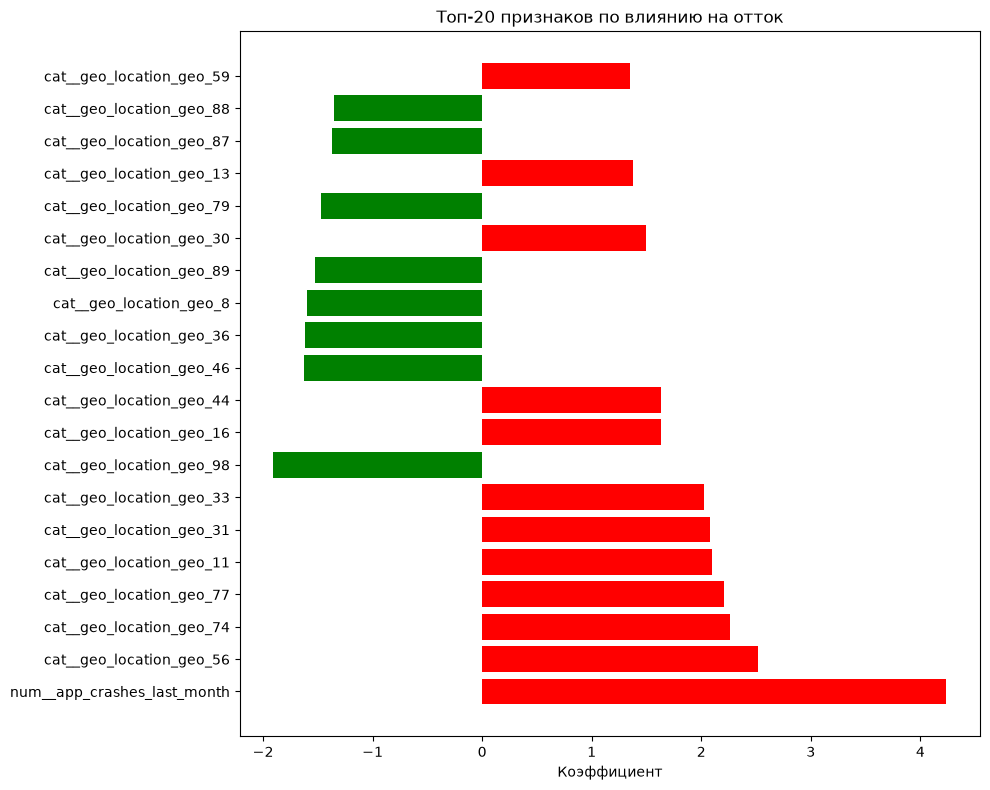

In [28]:
# Визуализирую топ-20 коэффициентов
plt.figure(figsize=(10, 8))
top_coefs = coef_df.head(20)
colors = ['green' if x < 0 else 'red' for x in top_coefs['coefficient']] # Красный - значительно влияет на отток
plt.barh(top_coefs['feature'], top_coefs['coefficient'], color=colors)
plt.xlabel('Коэффициент')
plt.title('Топ-20 признаков по влиянию на отток')
plt.tight_layout()
plt.show()

In [29]:
# Для удаления лишних для модели признаков использую обучение с l1-регуляризацией, т.к. она автоматически зануляет незначимые коэффициенты
pipeline_l1 = Pipeline(steps=[
    ('feature_engineer', FeatureEngineer()),
    ('preprocessor', preprocessor_updated),
    ('classifier', LogisticRegression(
        random_state=RANDOM_STATE, 
        max_iter=1000, 
        class_weight='balanced',
        penalty='l1',         # L1-регуляризация
        solver='liblinear'
    ))
])
pipeline_l1.fit(X_train, y_train)
# Получаю коэффициенты после L1-регуляризации
coefs_l1 = pipeline_l1.named_steps['classifier'].coef_[0]
feature_names = pipeline_l1.named_steps['preprocessor'].get_feature_names_out()

# Считаю сколько признаков осталось
n_nonzero = np.sum(np.abs(coefs_l1) > 1e-6)
print(f"Признаков после L1-регуляризации: {n_nonzero} из {len(coefs_l1)}")

Признаков после L1-регуляризации: 125 из 152


In [30]:
coef_df_l1 = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefs_l1
})
coef_df_l1['abs_coef'] = np.abs(coef_df_l1['coefficient'])
coef_df_l1 = coef_df_l1[coef_df_l1['abs_coef'] > 1e-6].sort_values('abs_coef', ascending=False)

print("\nТоп-20 признаков после L1-регуляризации:")
print(coef_df_l1.head(20)[['feature', 'coefficient']])


Топ-20 признаков после L1-регуляризации:
                         feature  coefficient
11   num__app_crashes_last_month     4.285045
104     cat__geo_location_geo_56     2.862382
150     cat__geo_location_geo_98    -2.716395
124     cat__geo_location_geo_74     2.577877
127     cat__geo_location_geo_77     2.515505
55      cat__geo_location_geo_11     2.405318
77      cat__geo_location_geo_31     2.371636
79      cat__geo_location_geo_33     2.278090
93      cat__geo_location_geo_46    -2.220420
82      cat__geo_location_geo_36    -2.123346
130      cat__geo_location_geo_8    -2.122190
60      cat__geo_location_geo_16     1.932525
91      cat__geo_location_geo_44     1.848278
129     cat__geo_location_geo_79    -1.777946
140     cat__geo_location_geo_89    -1.731124
76      cat__geo_location_geo_30     1.699690
139     cat__geo_location_geo_88    -1.628272
57      cat__geo_location_geo_13     1.615196
138     cat__geo_location_geo_87    -1.538982
145     cat__geo_location_geo_93     1

In [31]:
# Сравниваю модели с отбором признаков

# Модель с L1-регуляризацией (автоматический отбор)
results_l1 = cv_metrics(pipeline_l1, X_train, y_train, cv, 'LogisticRegression + L1')

# Сравнительная таблица
comparison_df = pd.DataFrame([
    results_l1,
    fe_results[0],  # без FE
    fe_results[1],  # с FE
])

print(comparison_df)

                                     Модель  Recall  Precision  PR AUC
0                   LogisticRegression + L1  0.8229     0.2926  0.6049
1                LogisticRegression(без FE)  0.8209     0.2867  0.5920
2  LogisticRegression + Feature Engineering  0.8110     0.2904  0.6117


---
**Промежуточный вывод**
1. Создание новых признаков дало умеренный, но положительный прирост основной метрики PR AUC. Нелинейные преобразования исходных переменных помогают модели лучше улавливать закономерности в данных.
2. Технические проблемы (`app_crashes_last_month`) оказались самым сильным фактором оттока. Географический признак (`geo_location_*`) имеет очень большой вес в модели, что указывает на значительные региональные различия в поведении клиентов. 
3. Для удаления неинформативных признаков была применена L1-регуляризация (Lasso), которая автоматически зануляет коэффициенты незначимых переменных. До применения L1: 152 признака. После применения L1: 125 признаков (было удалено 27 незначимых признаков). L1-регуляризация успешно справилась с отбором признаков, оставив в модели только наиболее важные переменные. Географические признаки и технические проблемы пользователей остаются главными причинами оттока, что важно для бизнес-интерпретации. Recall вернулся на уровень выше, чем у модели без FE (0.8229 против 0.8209). PR AUC немного снизился с 0.6117 до 0.6049, что может быть связано с удалением части полезных признаков, но модель стала проще и устойчивее к переобучению.

## Этап 6. Эксперименты с гиперпараметрами

1. Перечислите все гиперпараметры, с которыми планируете экспериментировать.

2. Проведите систематический перебор гиперпараметров для `LogisticRegression`, выполните кросс-валидацию для каждой конфигурации.

3. Составьте таблицу с результатами.

4. Выберите лучшую модель, ориентируясь на заданную метрику качества.

In [32]:
# Определяю гиперпараметры для перебора
# C       -- сила регуляризации: меньше C -> сильнее регуляризация -> проще модель
# penalty -- тип регуляризации: l2 (сглаживание), l1 (обнуляет несущественные признаки)
# class_weight="balanced" зафиксирован: этап 4 показал его стабильное превосходство
# solver="liblinear", cv=5 и tol=1e-2 -- для скорости
param_grid = {
    'classifier__C': [0.001, 0.01, 0.1, 1, 10],
    'classifier__penalty': ['l1', 'l2']
}
base_pipe_gs = Pipeline([
    ("feature_engineer", FeatureEngineer()),
    ("preprocessor",     preprocessor_updated),
    ("classifier",       LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=300,
        solver="liblinear",
        class_weight="balanced",
        tol=1e-2
    ))
])
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
n_combos = len(param_grid["classifier__C"]) * len(param_grid["classifier__penalty"])
print(f"Комбинаций: {n_combos}  x  5 фолда = {n_combos * 5} обучений")

grid_search = GridSearchCV(
    estimator=base_pipe_gs,
    param_grid=param_grid,
    scoring='average_precision',  # Основная метрика — PR AUC
    cv=5,
    n_jobs=-1,
    verbose=1,
    refit=True
)

grid_search.fit(X_train, y_train)
best_grid_pipeline = grid_search.best_estimator_
results_grid = cv_metrics (best_grid_pipeline, X_train, y_train, cv, 'LogisticRegression GridSearch')
# Вывожу лучшие параметры 
print("Лучшие гиперпараметры:")
print(grid_search.best_params_)
print(f"\nЛучший PR AUC (CV): {grid_search.best_score_:.4f}")

Комбинаций: 10  x  5 фолда = 50 обучений
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Лучшие гиперпараметры:
{'classifier__C': 0.01, 'classifier__penalty': 'l1'}

Лучший PR AUC (CV): 0.6668


In [33]:
# Составляю таблицу с результатами
comparison_df = pd.DataFrame([
    results_l1,
    fe_results[0],  # без FE
    fe_results[1],  # с FE
    results_grid
])
comparison_df

,Модель,Recall,Precision,PR AUC
0,LogisticRegression + L1,0.8229,0.2926,0.6049
1,LogisticRegression(без FE),0.8209,0.2867,0.5920
2,LogisticRegression + Feature Engineering,0.8110,0.2904,0.6117
3,LogisticRegression GridSearch,0.8746,0.2508,0.6721


---
**Промежуточный вывод**
1. Лучшая конфигурация: Подбор гиперпараметров показал, что лучшие результаты достигаются при использовании L1-регуляризации (penalty='l1') с относительно сильным коэффициентом регуляризации (C=0.01). Это говорит о том, что модель выигрывает от разреженности весов, отбрасывая неинформативные признаки.
2. Рост качества: Настройка гиперпараметров позволила значительно улучшить основную метрику. PR AUC вырос с 0.6117 (лучшая модель с FE) до 0.6721 на кросс-валидации.
3. Баланс метрик: Модель с подбором гиперпараметров демонстрирует высокий Recall (0.8746), что критически важно для задачи удержания клиентов (мы находим большую часть потенциальных "уходящих" клиентов). Платой за это является некоторое снижение Precision (0.2508), что означает больше ложных срабатываний, но в данном бизнес-контексте это является приемлемым компромиссом.

## Этап 7. Подготовка финальной модели

Объедините лучшую конфигурацию гиперпараметров с оптимальным набором признаков. Обучите модель на всех данных для кросс-валидации и проведите финальную оценку на отложенной тестовой выборке.


In [34]:
# Лучшая модель - best_grid_pipeline
final_model = best_grid_pipeline
# GridSearchCV с refit=True уже переобучила лучшую модель на всём train
y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]

# Оценка на тестовой выборке 
test_recall    = recall_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred, zero_division=0)
test_pr_auc    = average_precision_score(y_test, y_proba)

print(f"\n Метрики на тестовой выборке: ")
print(f"  Recall:    {test_recall:.4f}")
print(f"  Precision: {test_precision:.4f}")
print(f"  PR AUC:    {test_pr_auc:.4f}")

print(f"\n Детальный отчёт классификации: ")
print(classification_report(y_test, y_pred, target_names=['Остался (0)', 'Ушёл (1)']))



 Метрики на тестовой выборке: 
  Recall:    0.8730
  Precision: 0.2743
  PR AUC:    0.7221

 Детальный отчёт классификации: 
              precision    recall  f1-score   support

 Остался (0)       0.99      0.85      0.92      1964
    Ушёл (1)       0.27      0.87      0.42       126

    accuracy                           0.85      2090
   macro avg       0.63      0.86      0.67      2090
weighted avg       0.95      0.85      0.89      2090



In [35]:
# Сравниваю метрики на кросс-валидации и на тесте
final_results = pd.DataFrame([
    {
        "Модель": "LogisticRegression GridSearch (CV)",
        "Recall": results_grid["Recall"],
        "Precision": results_grid["Precision"],
        "PR AUC": results_grid["PR AUC"]
    },
    {
        "Модель": "LogisticRegression GridSearch (Test)",
        "Recall": round(test_recall, 4),
        "Precision": round(test_precision, 4),
        "PR AUC": round(test_pr_auc, 4)
    }
])
final_results

,Модель,Recall,Precision,PR AUC
0,LogisticRegression GridSearch (CV),0.8746,0.2508,0.6721
1,LogisticRegression GridSearch (Test),0.8730,0.2743,0.7221


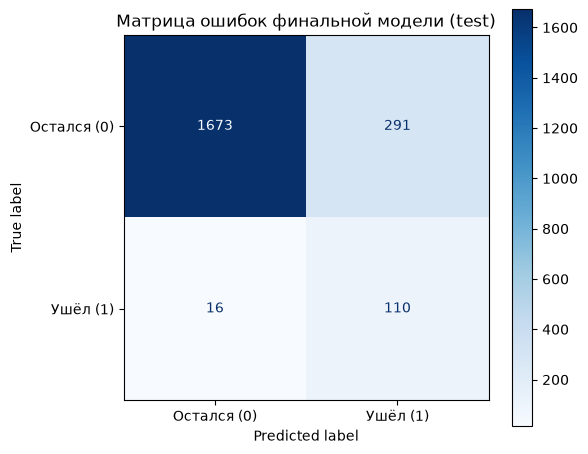

In [36]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Остался (0)', 'Ушёл (1)'])
disp.plot(cmap='Blues', ax=ax)
ax.set_title('Матрица ошибок финальной модели (test)')
plt.tight_layout()
plt.show()

## Этап 8. Отчёт о проделанной работе

Проанализируйте итоговые метрики модели и факторы, которые на них повлияли. Составьте описание, выделив наиболее важные факторы.

1. **Итоговое качество модели**
Финальная модель LogisticRegression с L1-регуляризацией показала следующие результаты на тестовой выборке: PR AUC достиг значения 0.7221, что значительно превосходит базовый уровень случайного угадывания (0.06). Модель находит 87% всех реально уходящих клиентов (Recall), при этом каждый четвёртый клиент, которого модель помечает как потенциально уходящего, действительно покидает сервис (Precision 27%). Такой баланс метрик является приемлемым для бизнеса: лучше предложить скидку четырём клиентам и удержать одного, чем пропустить реальный отток.

2. **Ключевые факторы оттока**
`Технические проблемы` оказались самым сильным предиктором оттока: каждый сбой в работе приложения значительно увеличивает вероятность ухода клиента. Это указывает на критическую важность стабильности мобильного приложения для удержания аудитории.
`Географический признак` показал высокую предсказательную силу: клиенты из определённых регионов уходят значительно чаще. Это может свидетельствовать о проблемах с логистикой, качестве обслуживания или недостаточной представленности сервиса в этих локациях.
Среди других значимых факторов оттока - `давние заказы` (клиенты "засыпают") и `чрезмерное использование скидок` (клиенты-охотники за акциями). Защитными факторами, снижающими риск оттока, выступают: `высокие оценки в последних заказах`, `наличие подписки` и `регулярная частота заказов`.

3. **Бизнес-рекомендации**
- В первую очередь необходимо усилить тестирование мобильного приложения и оперативно устранять технические сбои, так как это наиболее критичный фактор оттока. 
- Также рекомендуется провести аудит логистики и качества обслуживания в регионах с повышенным риском оттока для выявления и устранения системных проблем.
- Для работы с клиентами, у которых модель предсказывает высокий риск оттока, целесообразно внедрить систему раннего оповещения с автоматической отправкой персональных предложений (скидки, промокоды, специальные акции). Это позволит удерживать до 87% клиентов, которые уже начали "остывать".
- Политику скидок стоит пересмотреть: предлагать их не всем подряд, а точечно - клиентам с высоким риском оттока. Это повысит эффективность маркетинговых акций.

4. **Выводы**
Разработанная модель готова к использованию в продакшене. Она позволяет с высокой точностью выявлять клиентов на грани оттока, выделять ключевые причины ухода и принимать адресные меры по удержанию. Внедрение модели поможет компании сократить затраты на привлечение новых клиентов, повысить лояльность существующих. Рекомендуется запустить модель в пилотном режиме, измерить реальный эффект и масштабировать решение на всех клиентов.

## Этап 9. Сохранение модели для продакшена

Сохраните итоговую модель и пайплайн предобработки. Убедитесь, что всё работает: загрузите артефакты и проверьте их на тестовых данных. В решении укажите ссылку для скачивания сохранённых файлов.

In [37]:
# Создаю директорию для сохранения модели
os.makedirs('models', exist_ok=True)

MODEL_PATH    = 'models/churn_model.pkl'

# Сохраняю финальный пайплайн
joblib.dump(final_model, MODEL_PATH)
print(f"Модель сохранена: {MODEL_PATH}")

# Сохраняю список признаков для проверки
feature_columns = X_train.columns.tolist()
with open('models/feature_columns.txt', 'w') as f:
    for col in feature_columns:
        f.write(f"{col}\n")
print("Список признаков сохранён: models/feature_columns.txt")

Модель сохранена: models/churn_model.pkl
Список признаков сохранён: models/feature_columns.txt


In [40]:
# Проверяю загруженную модель
loaded_model = joblib.load(MODEL_PATH)

# Проверяю на тестовой выборке
test_pred_loaded = loaded_model.predict(X_test)
test_proba_loaded = loaded_model.predict_proba(X_test)[:, 1]

# Сравниваю с оригинальными предсказаниями
original_pred = final_model.predict(X_test)
original_proba = final_model.predict_proba(X_test)[:, 1]

# Проверяю идентичность
if np.array_equal(test_pred_loaded, original_pred) and np.allclose(test_proba_loaded, original_proba):
    print("✅ Модель загружена корректно. Предсказания совпадают.")
else:
    print("❌ ВНИМАНИЕ! Предсказания различаются. Проверьте сохранение.")

✅ Модель загружена корректно. Предсказания совпадают.


Ссылка на GitHub: https://github.com/S-Fiep/churn_prediction